In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

dataset_path = '/content/drive/My Drive/images'

if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found.")
    print("Please ensure the 'images' folder exists in your Google Drive and the path is correct.")
else:
    print(f"Successfully found dataset path: {dataset_path}")
    class_counts = {}
    class_names = []

    for item_name in os.listdir(dataset_path):
        item_path = os.path.join(dataset_path, item_name)

        if os.path.isdir(item_path):
            class_names.append(item_name)
            image_count = 0

            for filename in os.listdir(item_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                    image_count += 1
            class_counts[item_name] = image_count

    if not class_names:
        print(f"No subfolders (classes) found in '{dataset_path}'. Please check the folder structure.")
    else:
        print("\nDataset Classes and Counts:")
        # Sort class names for consistent output
        for class_name in sorted(class_names):
            print(f"- {class_name}: {class_counts.get(class_name, 0)} images")

        print(f"\nTotal classes found: {len(class_names)}")


Mounted at /content/drive
Successfully found dataset path: /content/drive/My Drive/images

Dataset Classes and Counts:
- 6_October_Bridge: 15 images
- Abdeen_Palace: 17 images
- Abu_Ghurab: 1 images
- Abu_Haggag_Mosque: 37 images
- Abu_Qir_Bay: 1 images
- Abu_el-Abbas_el-Mursi_Mosque: 36 images
- Agiba_beach: 75 images
- Aguilkia_Island: 5 images
- Ahmed_Shawki_Museum: 4 images
- Al-Aqmar_Mosque: 25 images
- Al-Ashraf_Mosque: 17 images
- Al-Azhar_Park_(Cairo): 50 images
- Al-Fath_Mosque: 3 images
- Al-Ghuri_Complex: 39 images
- Al-Jawhara_Palace_museum: 4 images
- Al-Manyal_Palace_Museum: 22 images
- Al-Nur_Mosque: 9 images
- Al-Qurn: 13 images
- Al-Rifa'i_Mosque: 5 images
- Al-Salih_Tala'i_Mosque: 15 images
- Al-Sayeda_Nafeesah_Mosque: 6 images
- Al-Sayeda_Zainab_Mosque: 1 images
- Al-Shate'e_Mosque: 17 images
- Al_Fattah_Al_Alim_Mosque_(Cairo): 1 images
- Alexandria_National_Museum: 3 images
- Alexandria_Opera_House: 89 images
- Alexandria_Port: 4 images
- Alexandria_Stadium: 3 image

In [ ]:
import os
import shutil

SOURCE_DIR = "/content/drive/My Drive/images"

TARGET_DIR = "/content/egypt_gan_filtered"

MIN_IMAGES = 40

image_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tiff", ".webp")

os.makedirs(TARGET_DIR, exist_ok=True)

selected_classes = []

for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    if len(images) >= MIN_IMAGES:
        selected_classes.append((class_name, len(images)))

        target_class_path = os.path.join(TARGET_DIR, class_name)
        os.makedirs(target_class_path, exist_ok=True)

        for img_name in images:
            src = os.path.join(class_path, img_name)
            dst = os.path.join(target_class_path, img_name)

            if not os.path.exists(dst):
                shutil.copy2(src, dst)

print("Selected classes:")
total_images = 0

for class_name, count in sorted(selected_classes, key=lambda x: x[1], reverse=True):
    print(f"- {class_name}: {count} images")
    total_images += count

print("\nTotal selected classes:", len(selected_classes))
print("Total selected images:", total_images)
print("Filtered dataset saved to:", TARGET_DIR)

Selected classes:
- Elephantine: 185 images
- Siwa: 134 images
- Temple_of_Kom_Ombo: 98 images
- Great_Hypostyle_Hall_of_Karnak: 96 images
- Muizz_Street: 92 images
- Colossi_of_Memnon: 91 images
- Alexandria_Opera_House: 89 images
- Montaza_Palace: 86 images
- Saint_Catherine's_Monastery,_Mount_Sinai: 84 images
- Na'ama_Bay: 83 images
- Bayt_Al-Suhaymi: 82 images
- Bibliotheca_Alexandrina: 77 images
- Pyramid_of_Djoser: 76 images
- Agiba_beach: 75 images
- Pyramid_of_Khafra: 73 images
- Wadi_Degla: 67 images
- Gebel_el-Silsila: 66 images
- Saint_George_Church_in_Coptic_Cairo: 64 images
- Nabq_Protected_Area: 63 images
- Egyptian_National_Military_Museum: 61 images
- Unfinished_obelisk_in_Aswan: 60 images
- Temple_of_Khonsu_in_Karnak: 58 images
- Mortuary_Temple_of_Hatshepsut: 58 images
- Temple_of_Isis_in_Philae: 57 images
- Ramesseum: 55 images
- Bagawat: 55 images
- Ptolemaic_Temple_of_Hathor_in_Deir_el-Medina: 54 images
- Giza_pyramid_complex: 54 images
- Qubbet_el-Hawa: 53 images


In [ ]:
import os
import shutil
from PIL import Image, UnidentifiedImageError

SOURCE_DIR = "/content/egypt_gan_filtered"
CLEAN_DIR = "/content/egypt_gan_clean"

image_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tiff", ".webp")

os.makedirs(CLEAN_DIR, exist_ok=True)

bad_images = []
saved_images = 0

for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    clean_class_path = os.path.join(CLEAN_DIR, class_name)
    os.makedirs(clean_class_path, exist_ok=True)

    image_index = 1

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)

        if not file_name.lower().endswith(image_extensions):
            continue

        try:
            with Image.open(file_path) as img:
                img = img.convert("RGB")

                new_file_name = f"{image_index:05d}.jpg"
                new_file_path = os.path.join(clean_class_path, new_file_name)

                img.save(new_file_path, "JPEG", quality=95)

                image_index += 1
                saved_images += 1

        except (UnidentifiedImageError, OSError, ValueError) as e:
            bad_images.append(file_path)

print("Clean dataset created at:", CLEAN_DIR)
print("Saved valid images:", saved_images)
print("Bad images skipped:", len(bad_images))

if bad_images:
    print("\nBad images:")
    for img in bad_images:
        print(img)

Clean dataset created at: /content/egypt_gan_clean
Saved valid images: 2879
Bad images skipped: 0


In [18]:
import os
import json
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from google.colab import drive

drive.mount('/content/drive')

manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataroot = "/content/egypt_gan_clean"

workers = 2
batch_size = 32
image_size = 128

# Image channels
nc = 3

# Latent vector size
nz = 128

# Generator/discriminator feature size
ngf = 64
ndf = 64

num_epochs = 150

# Two-time-scale update rule: keep D a little slower so it does not overpower G.
lrG = 0.0002
lrD = 0.0001

beta1 = 0.5

real_label_value = 0.9
fake_label_value = 0.0

SAVE_DIR = "/content/egypt_landmarks_cgan"
os.makedirs(SAVE_DIR, exist_ok=True)

OUTPUT_IMAGE_DIR = "/content/cgan_outputs"
os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda:0


In [19]:
dataset = dset.ImageFolder(
    root=dataroot,
    transform=transforms.Compose([
        transforms.Resize(image_size + 32),
        transforms.RandomResizedCrop(image_size, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.10, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5, 0.5, 0.5),
            (0.5, 0.5, 0.5)
        ),
    ])
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=(device.type == "cuda"),
    drop_last=True
)

num_classes = len(dataset.classes)

print("Number of images:", len(dataset))
print("Number of classes:", num_classes)
print("Classes:", dataset.classes)
print("Batches per epoch:", len(dataloader))

# Save class mapping for API later
class_info = {
    "classes": dataset.classes,
    "class_to_idx": dataset.class_to_idx,
    "idx_to_class": {v: k for k, v in dataset.class_to_idx.items()}
}

with open(os.path.join(SAVE_DIR, "class_mapping.json"), "w", encoding="utf-8") as f:
    json.dump(class_info, f, ensure_ascii=False, indent=4)

print("Class mapping saved.")

Number of images: 2879
Number of classes: 43
Classes: ['Agiba_beach', 'Al-Azhar_Park_(Cairo)', 'Alexandria_Opera_House', 'Aswan_High_Dam', 'Bagawat', 'Bayt_Al-Suhaymi', 'Bent_Pyramid', 'Bibliotheca_Alexandrina', 'Colossi_of_Memnon', 'Deir_el-Bahari', 'Egyptian_National_Military_Museum', 'Elephantine', 'Fatimid_Cemetery_in_Aswan', 'Gayer-Anderson_Museum', 'Gebel_el-Silsila', 'Giza_Plateau', 'Giza_Zoo', 'Giza_pyramid_complex', 'Great_Hypostyle_Hall_of_Karnak', 'Great_Pyramid_of_Giza', 'Hanging_Church_(Cairo)', 'Islamic_Cairo', 'Khan_el-Khalili', 'Kiosk_of_Trajan_in_Philae', 'Montaza_Palace', 'Mortuary_Temple_of_Hatshepsut', 'Muizz_Street', "Na'ama_Bay", 'Nabq_Protected_Area', 'Ptolemaic_Temple_of_Hathor_in_Deir_el-Medina', 'Pyramid_of_Djoser', 'Pyramid_of_Khafra', 'Qubbet_el-Hawa', 'Ramesseum', "Saint_Catherine's_Monastery,_Mount_Sinai", 'Saint_George_Church_in_Coptic_Cairo', 'Siwa', 'Temple_of_Hibis', 'Temple_of_Isis_in_Philae', 'Temple_of_Khonsu_in_Karnak', 'Temple_of_Kom_Ombo', 'Unfin

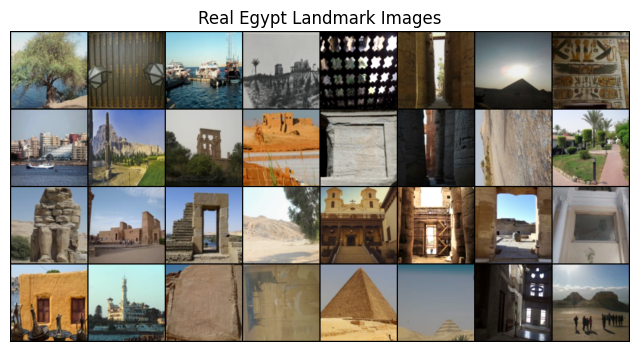

In [20]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Real Egypt Landmark Images")

plt.imshow(
    np.transpose(
        vutils.make_grid(
            real_batch[0].to(device)[:64],
            padding=2,
            normalize=True
        ).cpu(),
        (1, 2, 0)
    )
)

plt.show()

In [21]:
def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1 or classname.find("Linear") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# =========================
# 4. Conditional Generator
# =========================

class ConditionalGenerator(nn.Module):
    def __init__(self, nz, ngf, nc, num_classes, embed_size=128):
        super(ConditionalGenerator, self).__init__()

        self.label_emb = nn.Embedding(num_classes, embed_size)

        self.main = nn.Sequential(
            # Input: nz + embed_size
            nn.ConvTranspose2d(nz + embed_size, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),

            # 4x4 -> 8x8
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # 64x64 -> 128x128
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_emb(labels)
        label_embedding = label_embedding.view(label_embedding.size(0), label_embedding.size(1), 1, 1)

        x = torch.cat([noise, label_embedding], dim=1)
        return self.main(x)

# =========================
# 5. Conditional Discriminator
# =========================

class ConditionalDiscriminator(nn.Module):
    def __init__(self, nc, ndf, num_classes, image_size, embed_size=128):
        super(ConditionalDiscriminator, self).__init__()

        self.image_size = image_size
        self.label_emb = nn.Embedding(num_classes, image_size * image_size)

        self.main = nn.Sequential(
            # Input: image channels + 1 label channel
            nn.utils.spectral_norm(nn.Conv2d(nc + 1, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # 64x64
            nn.utils.spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32
            nn.utils.spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16
            nn.utils.spectral_norm(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8
            nn.utils.spectral_norm(nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1 logit. No Sigmoid here because BCEWithLogitsLoss is more stable.
            nn.utils.spectral_norm(nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False))
        )

    def forward(self, images, labels):
        label_embedding = self.label_emb(labels)
        label_embedding = label_embedding.view(labels.size(0), 1, self.image_size, self.image_size)

        x = torch.cat([images, label_embedding], dim=1)
        return self.main(x)

In [22]:
netG = ConditionalGenerator(
    nz=nz,
    ngf=ngf,
    nc=nc,
    num_classes=num_classes,
    embed_size=128
).to(device)

netD = ConditionalDiscriminator(
    nc=nc,
    ndf=ndf,
    num_classes=num_classes,
    image_size=image_size,
    embed_size=128
).to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

ConditionalGenerator(
  (label_emb): Embedding(43, 128)
  (main): Sequential(
    (0): ConvTranspose2d(256, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2),

In [23]:
criterion = nn.BCEWithLogitsLoss()

optimizerD = optim.Adam(netD.parameters(), lr=lrD, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lrG, betas=(beta1, 0.999))

G_losses = []
D_losses = []

# Fixed noise for visual checking
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Use repeated labels for visualization
fixed_labels = torch.arange(0, 64, device=device) % num_classes

print("Starting Improved Conditional DCGAN Training...")

for epoch in range(num_epochs):
    for i, (real_images, labels) in enumerate(dataloader, 0):

        real_images = real_images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        b_size = real_images.size(0)

        # =========================
        # 1. Train Discriminator
        # =========================

        netD.zero_grad(set_to_none=True)

        # Small random label smoothing helps reduce over-confident discriminator updates.
        real_targets = torch.empty(b_size, device=device).uniform_(0.85, 1.0)
        fake_targets = torch.empty(b_size, device=device).uniform_(0.0, 0.10)

        # Light instance noise early in training improves stability on small datasets.
        noise_std = max(0.0, 0.08 * (1.0 - epoch / (num_epochs * 0.5)))
        real_input = real_images + noise_std * torch.randn_like(real_images) if noise_std > 0 else real_images

        # Real images with real labels
        output_real = netD(real_input, labels).view(-1)
        errD_real = criterion(output_real, real_targets)
        errD_real.backward()

        D_x = torch.sigmoid(output_real).mean().item()

        # Fake images with same labels
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise, labels)
        fake_input = fake_images.detach() + noise_std * torch.randn_like(fake_images) if noise_std > 0 else fake_images.detach()

        output_fake = netD(fake_input, labels).view(-1)
        errD_fake = criterion(output_fake, fake_targets)
        errD_fake.backward()

        D_G_z1 = torch.sigmoid(output_fake).mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        # =========================
        # 2. Train Generator
        # =========================

        netG.zero_grad(set_to_none=True)

        # Generator wants discriminator to classify fake images as real.
        real_targets_for_G = torch.full((b_size,), real_label_value, dtype=torch.float, device=device)
        output_fake_for_G = netD(fake_images, labels).view(-1)
        errG = criterion(output_fake_for_G, real_targets_for_G)
        errG.backward()

        D_G_z2 = torch.sigmoid(output_fake_for_G).mean().item()

        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 50 == 0:
            print(
                f"[{epoch+1}/{num_epochs}] "
                f"[{i}/{len(dataloader)}] "
                f"Loss_D: {errD.item():.4f} "
                f"Loss_G: {errG.item():.4f} "
                f"D(x): {D_x:.4f} "
                f"D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f} "
                f"noise_std: {noise_std:.4f}"
            )

    # Generate sample images after every epoch
    with torch.no_grad():
        fake = netG(fixed_noise, fixed_labels).detach().cpu()

    vutils.save_image(
        fake,
        f"{OUTPUT_IMAGE_DIR}/epoch_{epoch+1:03d}.png",
        normalize=True,
        value_range=(-1, 1),
        nrow=8
    )

    # Save checkpoint every 25 epochs
    if (epoch + 1) % 25 == 0:
        torch.save(netG.state_dict(), os.path.join(SAVE_DIR, f"generator_epoch_{epoch+1}.pth"))
        torch.save(netD.state_dict(), os.path.join(SAVE_DIR, f"discriminator_epoch_{epoch+1}.pth"))

print("Improved Conditional GAN training finished.")

Starting Improved Conditional DCGAN Training...
[1/150] [0/89] Loss_D: 1.5425 Loss_G: 7.2419 D(x): 0.5589 D(G(z)): 0.5777/0.0132 noise_std: 0.0800
[1/150] [50/89] Loss_D: 1.0369 Loss_G: 3.0495 D(x): 0.7161 D(G(z)): 0.2594/0.0641 noise_std: 0.0800
[2/150] [0/89] Loss_D: 1.3715 Loss_G: 3.5916 D(x): 0.7515 D(G(z)): 0.4123/0.0342 noise_std: 0.0789
[2/150] [50/89] Loss_D: 1.5092 Loss_G: 4.5926 D(x): 0.7175 D(G(z)): 0.5294/0.0134 noise_std: 0.0789
[3/150] [0/89] Loss_D: 1.1010 Loss_G: 2.2714 D(x): 0.7232 D(G(z)): 0.3919/0.1152 noise_std: 0.0779
[3/150] [50/89] Loss_D: 1.0975 Loss_G: 1.3750 D(x): 0.5676 D(G(z)): 0.2075/0.2875 noise_std: 0.0779
[4/150] [0/89] Loss_D: 1.2775 Loss_G: 1.5024 D(x): 0.5452 D(G(z)): 0.2793/0.2452 noise_std: 0.0768
[4/150] [50/89] Loss_D: 1.2326 Loss_G: 1.4675 D(x): 0.6043 D(G(z)): 0.3564/0.2226 noise_std: 0.0768
[5/150] [0/89] Loss_D: 1.1174 Loss_G: 1.8506 D(x): 0.7126 D(G(z)): 0.4374/0.1679 noise_std: 0.0757
[5/150] [50/89] Loss_D: 1.3741 Loss_G: 2.0366 D(x): 0.694

In [24]:
torch.save(netG.state_dict(), os.path.join(SAVE_DIR, "conditional_generator.pth"))
torch.save(netD.state_dict(), os.path.join(SAVE_DIR, "conditional_discriminator.pth"))

config = {
    "image_size": image_size,
    "nc": nc,
    "nz": nz,
    "ngf": ngf,
    "ndf": ndf,
    "num_classes": num_classes,
    "classes": dataset.classes,
    "class_to_idx": dataset.class_to_idx
}

with open(os.path.join(SAVE_DIR, "cgan_config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

print("Final Conditional GAN saved to:", SAVE_DIR)

Final Conditional GAN saved to: /content/egypt_landmarks_cgan


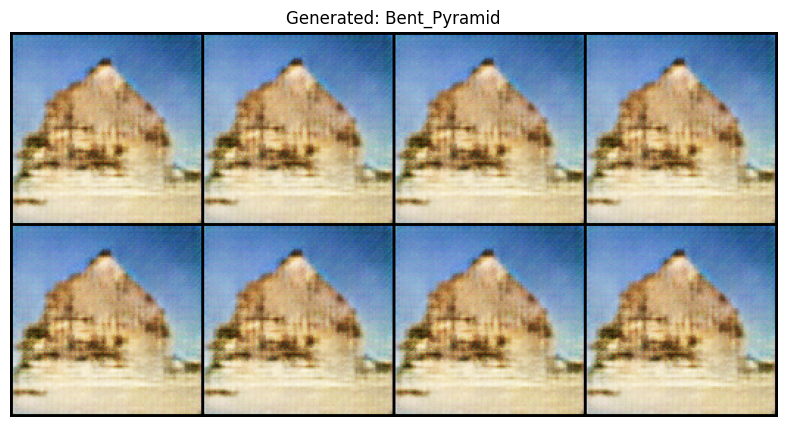

Saved to: /content/generated_Bent_Pyramid.png


'/content/generated_Bent_Pyramid.png'

In [29]:
def generate_by_class_name(class_name, num_images=8, truncation=0.8):
    netG.eval()

    if class_name not in dataset.class_to_idx:
        available = list(dataset.class_to_idx.keys())[:20]
        raise ValueError(
            f"Class '{class_name}' not found. "
            f"Example available classes: {available}"
        )

    class_idx = dataset.class_to_idx[class_name]

    labels = torch.full(
        (num_images,),
        class_idx,
        dtype=torch.long,
        device=device
    )

    # Truncated noise gives less variety but usually cleaner samples.
    noise = torch.randn(num_images, nz, 1, 1, device=device).clamp(-truncation, truncation)

    with torch.no_grad():
        fake_images = netG(noise, labels).detach().cpu()

    safe_class_name = class_name.replace("/", "_").replace(" ", "_")
    output_path = f"/content/generated_{safe_class_name}.png"

    vutils.save_image(
        fake_images,
        output_path,
        normalize=True,
        value_range=(-1, 1),
        nrow=4
    )

    plt.figure(figsize=(10, 5))
    plt.axis("off")
    plt.title(f"Generated: {class_name}")

    plt.imshow(
        np.transpose(
            vutils.make_grid(fake_images, padding=2, normalize=True, value_range=(-1, 1), nrow=4),
            (1, 2, 0)
        )
    )

    plt.show()

    print("Saved to:", output_path)

    return output_path

generate_by_class_name("Bent_Pyramid", num_images=8)

In [30]:
import os
import shutil
from google.colab import drive

# Ensure drive is mounted
drive.mount('/content/drive', force_remount=True)

# Define source directories (already exist in /content/)
cgan_outputs_dir = '/content/cgan_outputs'
egypt_landmarks_cgan_dir = '/content/egypt_landmarks_cgan'

# Define target directory in Google Drive
drive_upload_path = '/content/drive/My Drive/'

print(f"Uploading {cgan_outputs_dir} and {egypt_landmarks_cgan_dir} to {drive_upload_path}")

# --- Process cgan_outputs --- #
if os.path.exists(cgan_outputs_dir):
    cgan_outputs_zip_name = 'cgan_outputs'
    cgan_outputs_zip_path = shutil.make_archive(cgan_outputs_zip_name, 'zip', cgan_outputs_dir)
    shutil.move(cgan_outputs_zip_path, drive_upload_path)
    print(f"Successfully uploaded {cgan_outputs_zip_path} to Google Drive.")
else:
    print(f"Warning: {cgan_outputs_dir} not found. Skipping upload.")

# --- Process egypt_landmarks_cgan --- #
if os.path.exists(egypt_landmarks_cgan_dir):
    egypt_landmarks_cgan_zip_name = 'egypt_landmarks_cgan'
    egypt_landmarks_cgan_zip_path = shutil.make_archive(egypt_landmarks_cgan_zip_name, 'zip', egypt_landmarks_cgan_dir)
    shutil.move(egypt_landmarks_cgan_zip_path, drive_upload_path)
    print(f"Successfully uploaded {egypt_landmarks_cgan_zip_path} to Google Drive.")
else:
    print(f"Warning: {egypt_landmarks_cgan_dir} not found. Skipping upload.")

print("Upload process complete.")

Mounted at /content/drive
Uploading /content/cgan_outputs and /content/egypt_landmarks_cgan to /content/drive/My Drive/
Successfully uploaded /content/cgan_outputs.zip to Google Drive.
Successfully uploaded /content/egypt_landmarks_cgan.zip to Google Drive.
Upload process complete.
